In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = "/content/Image (1).jpg"
img = cv2.imread(path, 0)

def region_growing(image, seed, threshold=10):
  h, w = image.shape
  segmented = np.zeros((h, w), np.uint8)
  stack = [seed]
  seed_value = image[seed]

  while stack:
    x, y = stack.pop()

    if segmented[x, y] == 0:
      segmented[x, y] = 255

      for dx in [-1,0,1]:
        for dy in [-1,0,1]:
          nx, ny = x+dx, y+dy
          if 0 <= nx < h and 0 <= ny < w:
            if abs(int(image[nx, ny]) - int(seed_value)) < threshold:
              stack.append((nx, ny))

  return segmented

In [4]:
seed = (img.shape[0]//2, img.shape[1]//2)
rg_result = region_growing(img, seed)

In [5]:
def split(image, threshold=15):
  h, w = image.shape
  result = np.zeros_like(image)

  def recursive(x, y, h, w):
    region = image[x:x+h, y:y+w]
    if h < 8 or w < 8 or np.std(region) < threshold:
      result[x:x+h, y:y+w] = np.mean(region)
    else:
      recursive(x, y, h//2, w//2)
      recursive(x+h//2, y, h//2, w//2)
      recursive(x, y+w//2, h//2, w//2)
      recursive(x+h//2, y+w//2, h//2, w//2)

  recursive(0,0,h,w)

  return result
split_result = split(img)

In [6]:
def merge(image, threshold=10):
  blurred = cv2.GaussianBlur(image,(5,5),0)
  diff = cv2.absdiff(image, blurred)
  _, merged = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY_INV)

  return merged

merge_result = merge(img)

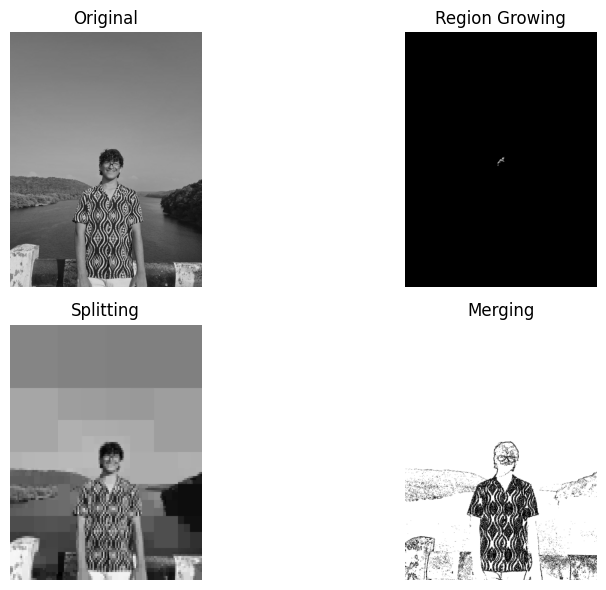

In [7]:
titles = ["Original", "Region Growing", "Splitting", "Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,6))
for i in range(4):
  plt.subplot(2,2,i+1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
seed = (200,200)
threshold = 100

rg_result = region_growing(img, seed)

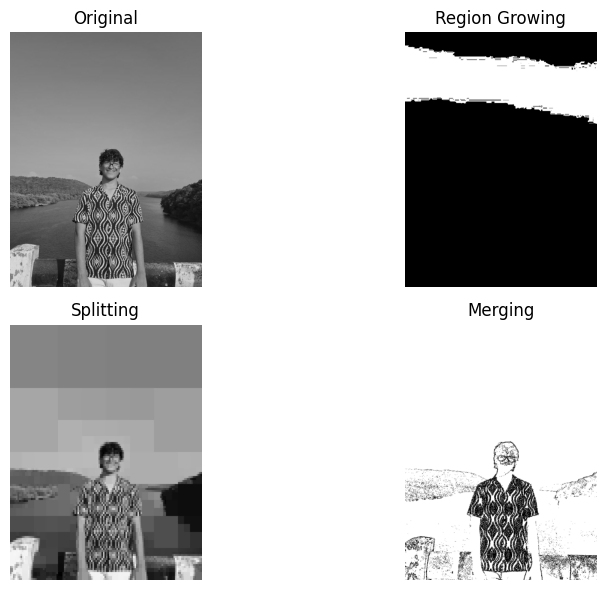

In [9]:
titles = ["Original", "Region Growing", "Splitting", "Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,6))
for i in range(4):
  plt.subplot(2,2,i+1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3743/1807052380.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),256,[0,256])


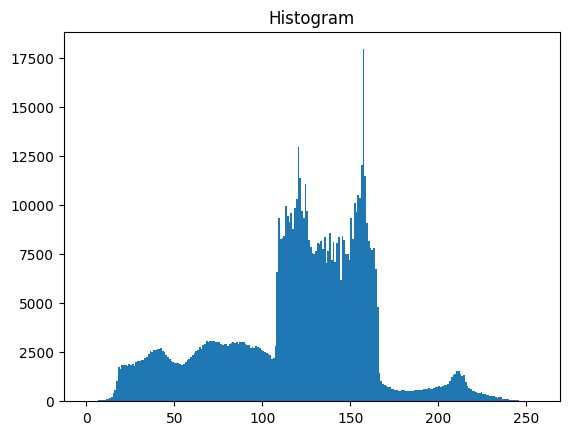

In [10]:
plt.hist(img.ravel(),256,[0,256])
plt.title("Histogram")
plt.show()

In [11]:
otsu_value, _ = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
threshold = int(otsu_value * 0.25)

In [12]:
_, binary = cv2.threshold(img,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

ys, xs = np.where(binary==255)

seed = (ys[len(ys)//2], xs[len(xs)//2])
rg_result = region_growing(img, seed, threshold)

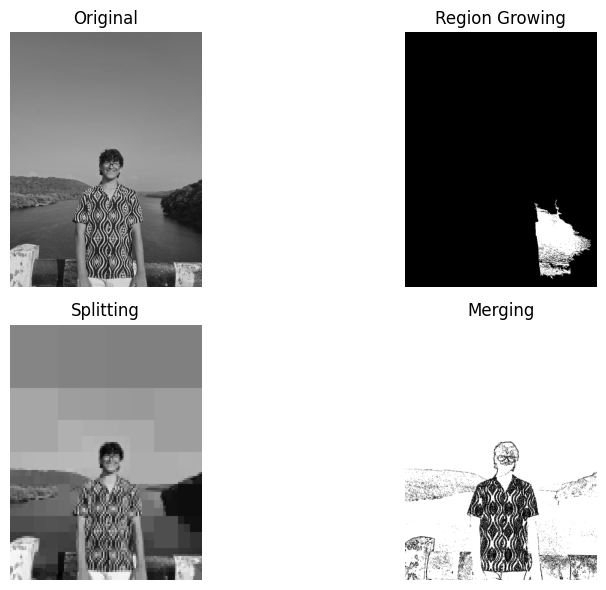

In [13]:
titles = ["Original", "Region Growing", "Splitting", "Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,6))
for i in range(4):
  plt.subplot(2,2,i+1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
otsu_value, _ = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
threshold = int(otsu_value * 0.7)

In [17]:
_, binary = cv2.threshold(img,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

ys, xs = np.where(binary==255)

seed = (ys[len(ys)//2], xs[len(xs)//2])
rg_result = region_growing(img, seed, threshold)

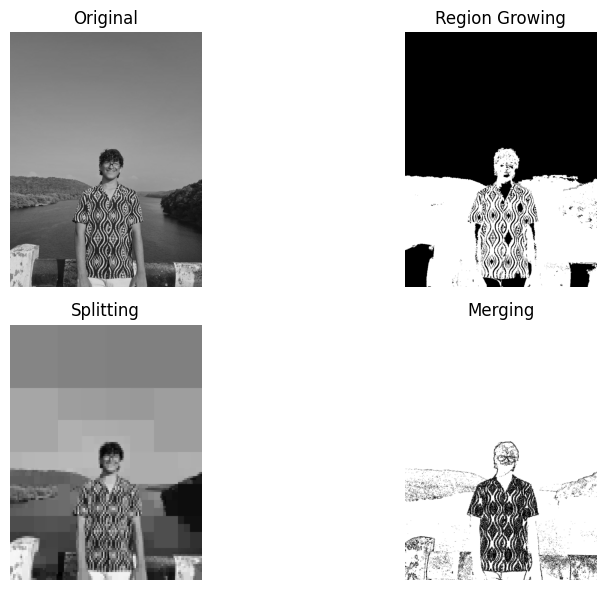

In [18]:
titles = ["Original", "Region Growing", "Splitting", "Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,6))
for i in range(4):
  plt.subplot(2,2,i+1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis("off")

plt.tight_layout()
plt.show()

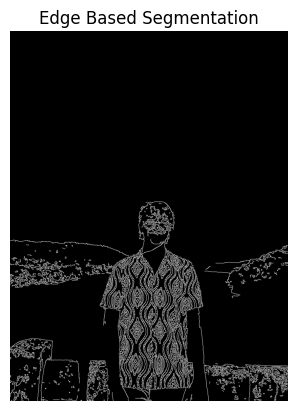

In [19]:
edges = cv2.Canny(img, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Based Segmentation")
plt.axis("off")
plt.show()

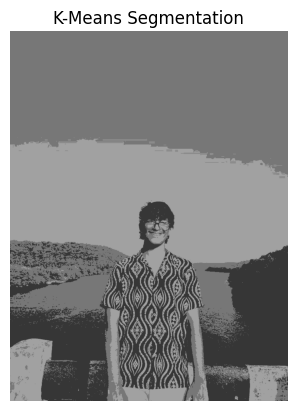

In [20]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 3
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)

segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img_rgb.shape)

plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")
plt.show()